# Homework 8 - Horizontal Wells
### Daniel McAllister-Ou
---
imports: 

In [412]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


---
Define drawdown data set: 

In [413]:

data = {
    "Time_hrs": [
        0.000000E+00,
        1.000000E-03,
        1.167927E-03,
        1.364054E-03,
        1.593115E-03,
        1.860643E-03,
        2.173095E-03,
        2.538016E-03,
        2.964218E-03,
        3.461991E-03,
        4.043352E-03,
        4.722341E-03,
        5.515350E-03,
        6.441526E-03,
        7.523233E-03,
        8.786588E-03,
        1.026209E-02,
        1.198538E-02,
        1.399805E-02,
        1.634870E-02,
        1.909409E-02,
        2.230050E-02,
        2.604536E-02,
    ],
    "Pressure_psig": [
        5000.000,
        4994.236,
        4993.362,
        4992.379,
        4991.277,
        4990.053,
        4988.704,
        4987.223,
        4985.617,
        4983.887,
        4982.034,
        4980.067,
        4978.010,
        4975.875,
        4973.665,
        4971.408,
        4969.119,
        4966.813,
        4964.508,
        4962.217,
        4959.956,
        4957.732,
        4955.551,
    ]
}

data_append = {
    "Time_hrs": [
        3.041908E-02, 3.552727E-02, 4.149326E-02, 4.846110E-02,
        5.659903E-02, 6.610354E-02, 7.720412E-02, 9.016878E-02,
        1.053106E-01, 1.229951E-01, 1.436493E-01, 1.677719E-01,
        1.959453E-01, 2.288498E-01, 2.672799E-01, 3.121634E-01,
        3.645841E-01, 4.258077E-01, 4.973123E-01, 5.808246E-01,
        6.783607E-01, 7.922758E-01, 9.253204E-01, 1.080707,
        1.262187, 1.474142, 1.721690, 2.010809,
        2.348478, 2.742851, 3.203450, 3.741396,
        4.369678, 5.103466, 5.960475, 6.961401,
        8.130408, 9.495725, 11.09031, 12.95268,
        15.12778
    ],
    "Pressure_psig": [
        4953.426, 4951.352, 4949.331, 4947.370,
        4945.458, 4943.594, 4941.782, 4940.011,
        4938.280, 4936.591, 4934.935, 4933.313,
        4931.723, 4930.157, 4928.612, 4927.081,
        4925.553, 4924.018, 4922.458, 4920.862,
        4919.209, 4917.483, 4915.669, 4913.742,
        4911.688, 4909.496, 4907.144, 4904.659,
        4901.982, 4899.073, 4895.937, 4892.558,
        4888.885, 4884.926, 4880.657, 4876.022,
        4871.026, 4865.634, 4859.787, 4853.481,
        4846.671
    ]
}

data_append_2 = {
    "Time_hrs": [
        17.66815,
        20.63511,
        24.10030,
        28.14739,
        32.87410,
        38.39456
    ],
    "Pressure_psig": [
        4839.292,
        4831.334,
        4822.735,
        4813.426,
        4803.384,
        4792.534
    ]
}

data_append_3 = {
    'Time_hrs': [
        44.842040, 52.372240, 61.166950, 71.438550, 83.435010,
        97.446010, 113.80980, 132.92160, 155.24270, 181.31220,
        211.75940, 247.31950, 288.85120, 337.35710, 394.00850,
        460.17320, 537.44880, 627.70100, 733.10900, 856.21780,
        1000.0000
    ],
    'Pressure_psig': [
        4780.809, 4768.181, 4754.578, 4739.958, 4724.309,
        4707.601, 4689.843, 4671.046, 4651.255, 4630.510,
        4608.839, 4586.355, 4563.092, 4539.082, 4514.415,
        4489.210, 4463.524, 4437.333, 4410.756, 4383.847,
        4356.588
    ]
}

df = pd.DataFrame(data)
df_append = pd.DataFrame(data_append)
df_append_2 = pd.DataFrame(data_append_2)
df_append_3 = pd.DataFrame(data_append_3)
df = pd.concat([df, df_append, df_append_2, df_append_3], ignore_index=True)

df.head(21)

,Time_hrs,Pressure_psig
0,0.000000,5000.000
1,0.001000,4994.236
2,0.001168,4993.362
3,0.001364,4992.379
4,0.001593,4991.277
5,0.001861,4990.053
6,0.002173,4988.704
7,0.002538,4987.223
8,0.002964,4985.617
9,0.003462,4983.887


---
We aim to analyze this drawdown test and complete the following tasks
1. Identify flow regimes 
1. Find Formation Permeabilities (kx, ky, kz)
1. Find skin factors (Sm and Sz)
---

Define 'other pertinent data':

In [414]:
Q = 1000 # STB/D
Horizontal_length = 2000 # ft
formation_pay_thickness = 40 # ft
porosity = 0.15
Rw = 0.4 # ft 
oil_viscosity = 0.45 # cp
compressibility = 20E-6 # 1/psi
Bo = 1.5 # RB/STB



Compute Derivative Curve:

C:\Users\txjam\AppData\Roaming\Python\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


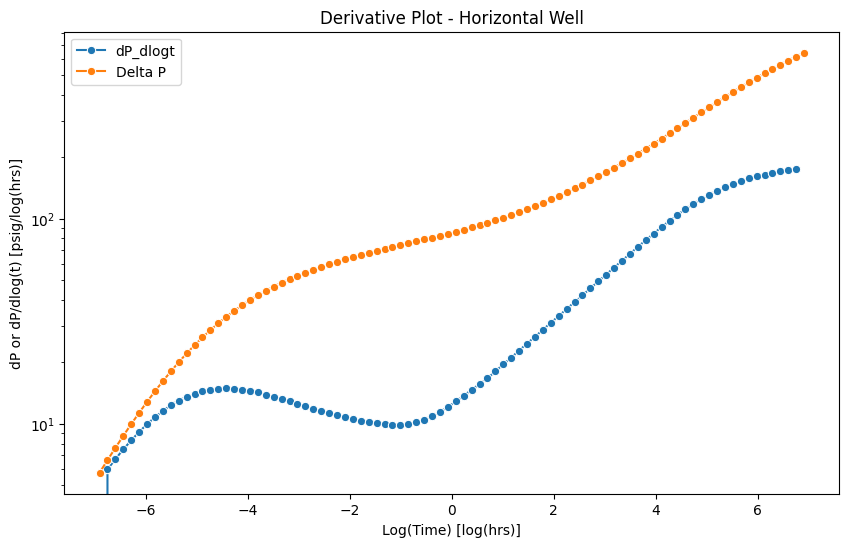

In [415]:
deriv_data = df.copy()
Pi = 5000 # psig 
deriv_data['log time'] = np.log(deriv_data['Time_hrs'])
deriv_data['delta P'] = Pi - deriv_data['Pressure_psig']  
dP = deriv_data['delta P'].values
logt = deriv_data['log time'].values
dP_dlogt = np.full(len(dP), np.nan)

for i in range(1, len(dP)-1):
    dP_dlogt[i] = (dP[i+1] - dP[i-1]) / (logt[i+1] - logt[i-1])

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=logt, y=dP_dlogt, marker='o',label='dP_dlogt',ax=ax)
sns.lineplot(x=logt,y=dP,marker='o',label='Delta P',ax=ax)
ax.set_title('Derivative Plot - Horizontal Well')
ax.set_xlabel('Log(Time) [log(hrs)]')
ax.set_ylabel('dP or dP/dlog(t) [psig/log(hrs)]')
ax.set_yscale('log')
ax.legend()


Identify Flow Regimes:

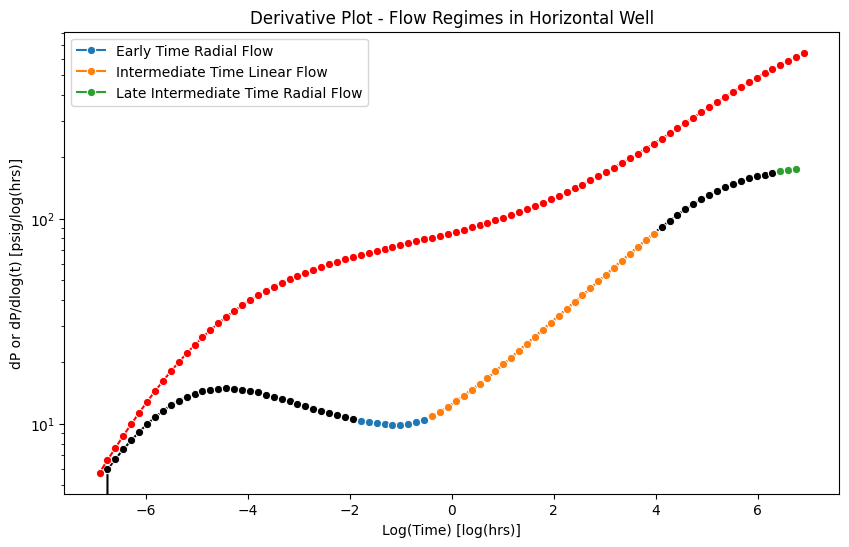

In [416]:
mask_earlytime_radial_flow = np.logical_and(logt > -1.9, logt < -0.5)
ETRF_logt = logt[mask_earlytime_radial_flow]
ETRF_dP_dlogt = dP_dlogt[mask_earlytime_radial_flow]

mask_intermediate_time_linear_flow = np.logical_and(logt > -0.5, logt < 4.0)
ITLF_logt = logt[mask_intermediate_time_linear_flow]
ITLF_dP_dlogt = dP_dlogt[mask_intermediate_time_linear_flow]

mask_late_intermediate_time_radial_flow = logt > 6.35
LITRF_logt = logt[mask_late_intermediate_time_radial_flow]
LITRF_dP_dlogt = dP_dlogt[mask_late_intermediate_time_radial_flow]



fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=logt, y=dP_dlogt, marker='o',label='',color='k',ax=ax)
sns.lineplot(x=logt,y=dP,marker='o',label='',color='r',ax=ax)
sns.lineplot(x=ETRF_logt, y=ETRF_dP_dlogt, marker='o', label='Early Time Radial Flow', ax=ax)
sns.lineplot(x=ITLF_logt, y=ITLF_dP_dlogt, marker='o', label='Intermediate Time Linear Flow', ax=ax)
sns.lineplot(x=LITRF_logt, y=LITRF_dP_dlogt, marker='o', label='Late Intermediate Time Radial Flow', ax=ax)

ax.set_title('Derivative Plot - Flow Regimes in Horizontal Well')
ax.set_xlabel('Log(Time) [log(hrs)]')
ax.set_ylabel('dP or dP/dlog(t) [psig/log(hrs)]')
ax.set_yscale('log')
ax.legend()

Lets compute a semilog plot for early time radial flow:

Early Time Radial Flow Slope: 9.9783 psig/log(hrs)
Extrapolated Pwf at t=1 hr: 4915.47 psig


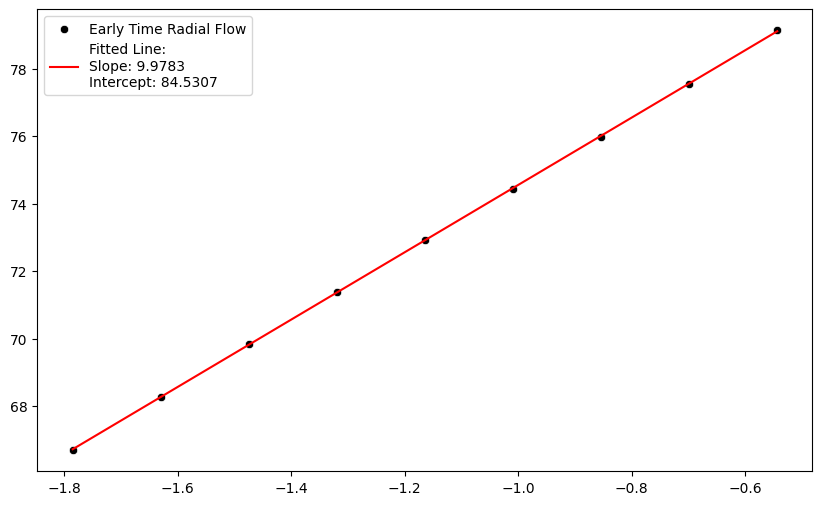

In [417]:
fig,ax = plt.subplots(figsize=(10,6))
dP_earlytime_radial_flow = dP[mask_earlytime_radial_flow]
slope_erf, intercept_erf = np.polyfit(ETRF_logt, dP_earlytime_radial_flow, 1)

ETRF_logt_min = ETRF_logt.min()
ETRF_logt_max = ETRF_logt.max()
linetime = np.linspace(ETRF_logt_min, ETRF_logt_max, 100)
fitted_line = slope_erf * linetime + intercept_erf

print(f'Early Time Radial Flow Slope: {slope_erf:.4f} psig/log(hrs)')

sns.scatterplot(x=ETRF_logt, y=dP_earlytime_radial_flow, marker='o',color='k', label='Early Time Radial Flow', ax=ax)
sns.lineplot(x=linetime, y=fitted_line, label=f'Fitted Line:\nSlope: {slope_erf:.4f}\nIntercept: {intercept_erf:.4f}',color='r', ax=ax)
# delta P = Pi - Pwf
pwf_0_erf = Pi - intercept_erf
print(f'Extrapolated Pwf at t=1 hr: {pwf_0_erf:.2f} psig')

sqrt(kzky) = 162.6 * q * mu * Bo / m / Lw

In [418]:
sqrt_kykz = 162.6 * Q * oil_viscosity * Bo / (Horizontal_length * slope_erf)
print(f'Calculated sqrt(kykz): {sqrt_kykz:.2f} md')

textbook_sqrt_kykz = 162.6 * 1000 * 0.45 * 1.5 / (2000 * 23.04)
print(f'Textbook sqrt(kykz): {textbook_sqrt_kykz:.2f} md')

Calculated sqrt(kykz): 5.50 md
Textbook sqrt(kykz): 2.38 md


Square Root Time plot for Intermediate time linear flow 

Intermediate Time Linear Flow Slope: 23.4987 psig/sqrt(hrs)


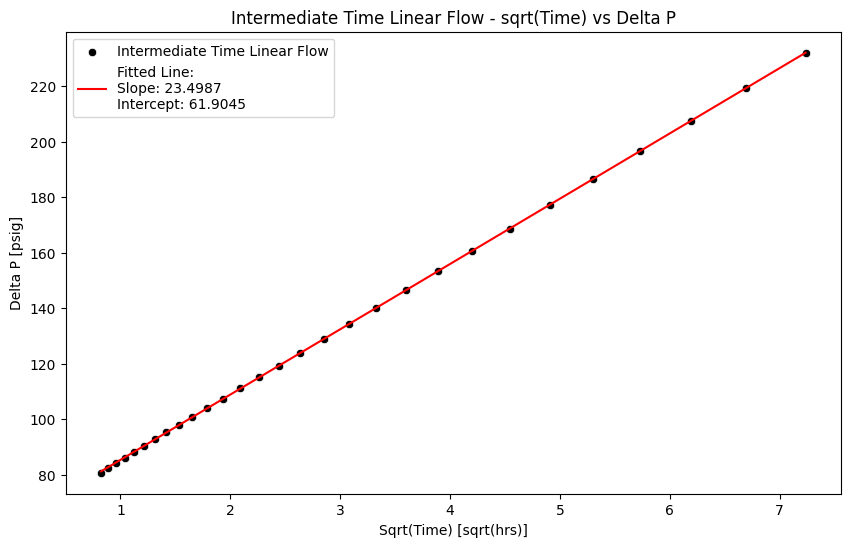

In [419]:
time = deriv_data['Time_hrs'].values
sqrt_time = np.sqrt(time)

sqrt_time_ITLF = sqrt_time[mask_intermediate_time_linear_flow]
dP_ITLF = dP[mask_intermediate_time_linear_flow]
slope_itlf, intercept_itlf = np.polyfit(sqrt_time_ITLF, dP_ITLF, 1)

sqrt_time_ITLF_min = sqrt_time_ITLF.min()
sqrt_time_ITLF_max = sqrt_time_ITLF.max()
linetime_itlf = np.linspace(sqrt_time_ITLF_min, sqrt_time_ITLF_max, 100)
fitted_line_itlf = slope_itlf * linetime_itlf + intercept_itlf
print(f'Intermediate Time Linear Flow Slope: {slope_itlf:.4f} psig/sqrt(hrs)')

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=sqrt_time_ITLF, y=dP_ITLF, marker='o', color='k', label='Intermediate Time Linear Flow', ax=ax)
sns.lineplot(x=linetime_itlf, y=fitted_line_itlf, label=f'Fitted Line:\nSlope: {slope_itlf:.4f}\nIntercept: {intercept_itlf:.4f}', color='r', ax=ax)
ax.set_title('Intermediate Time Linear Flow - sqrt(Time) vs Delta P')
ax.set_xlabel('Sqrt(Time) [sqrt(hrs)]')
ax.set_ylabel('Delta P [psig]')
ax.legend()

ky = (8.128 * Q * Bo / Lw / H / slope)**2 * mu / phi / Ct

In [420]:
ky = (8.128 * Q * Bo / Horizontal_length / formation_pay_thickness / slope_itlf) ** 2 * oil_viscosity / porosity / compressibility 
print(f'Calculated permeability (ky): {ky:.2f} md')



Calculated permeability (ky): 6.31 md


Semilog plot for late intermediate time radial flow

Late Intermediate Time Radial Flow Slope: -399.2303 psig/log10(hrs)


C:\Users\txjam\AppData\Local\Temp\ipykernel_28268\4278248078.py:2: RuntimeWarning: divide by zero encountered in log10
  log10_time = np.log10(deriv_data['Time_hrs'].values)


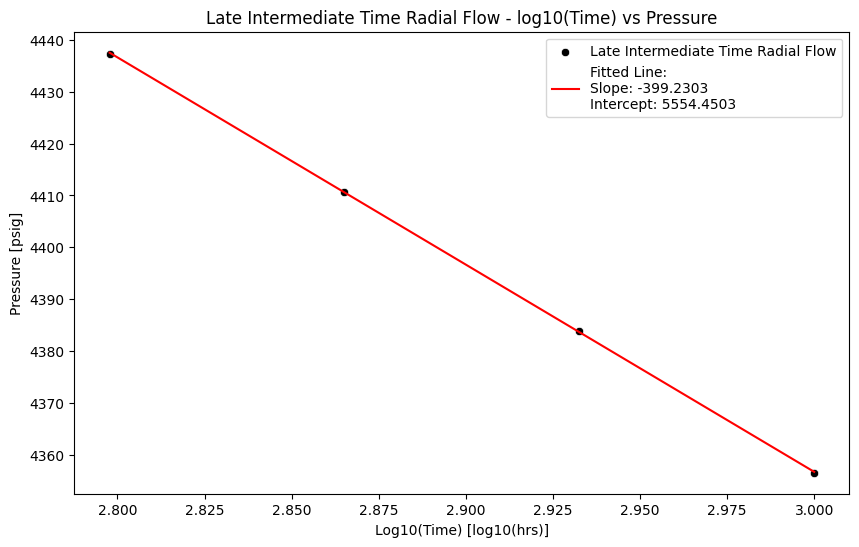

In [421]:
pressure_values = deriv_data['Pressure_psig'].values
log10_time = np.log10(deriv_data['Time_hrs'].values)

pressure_LITRF = pressure_values[mask_late_intermediate_time_radial_flow]
log10_time_LITRF = log10_time[mask_late_intermediate_time_radial_flow]
slope_litrf, intercept_litrf = np.polyfit(log10_time_LITRF, pressure_LITRF, 1)
print(f'Late Intermediate Time Radial Flow Slope: {slope_litrf:.4f} psig/log10(hrs)')

log10_time_LITRF_min = log10_time_LITRF.min()
log10_time_LITRF_max = log10_time_LITRF.max()
linetime_litrf = np.linspace(log10_time_LITRF_min, log10_time_LITRF_max, 100)
fitted_line_litrf = slope_litrf * linetime_litrf + intercept_litrf
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=log10_time_LITRF, y=pressure_LITRF, marker='o', color='k', label='Late Intermediate Time Radial Flow', ax=ax)
sns.lineplot(x=linetime_litrf, y=fitted_line_litrf, label=f'Fitted Line:\nSlope: {slope_litrf:.4f}\nIntercept: {intercept_litrf:.4f}', color='r', ax=ax)
ax.set_title('Late Intermediate Time Radial Flow - log10(Time) vs Pressure')
ax.set_xlabel('Log10(Time) [log10(hrs)]')
ax.set_ylabel('Pressure [psig]')
ax.legend()


sqrt(kx*ky) = 162.6 * Q * mu * Bo / thickness / abs(slope)

In [422]:
sqrt_kxky = 162.6 * Q * oil_viscosity * Bo / formation_pay_thickness / np.abs(slope_litrf)
print(f'Calculated sqrt(kxky): {sqrt_kxky:.2f} md')

textbook_sqrt_kxky = 162.6 * 1000 * 0.45 * 1.5 / 40 / 399.23
print(f'Textbook sqrt(kxky): {textbook_sqrt_kxky:.2f} md')

Calculated sqrt(kxky): 6.87 md
Textbook sqrt(kxky): 6.87 md


Calculate Kx and Kz

In [423]:
kx = (sqrt_kxky ** 2) / ky
print(f'Calculated kx: {kx:.2f} md')
kz = (sqrt_kykz ** 2) / ky
print(f'Calculated kz: {kz:.2f} md')

print(f' Calculated ky: {ky:.2f} md')

Calculated kx: 7.49 md
Calculated kz: 4.79 md
 Calculated ky: 6.31 md


Kz is higher than in textbook because the calculated slop for Early time radial flow was half that of the textbook. This caused sqrtkzky to be twice that of the textbook and the difference is exacerbated by squaring.

---
### Skin Determination 

Mechanical skin factor can be estimated from early time radial flow as: 

Sm = 1.1513 * [intercept_ETRF / slope_ETRF - log(sqrt(kzky) / phi / mu / ct / rw^2) + 3.23]

In [424]:
Sm = 1.1513 * (intercept_erf / slope_erf - np.log10(sqrt_kykz / porosity / oil_viscosity / compressibility / Rw**2) + 3.23)
Sm_textbook = 1.1513 * (84.5 / 20.04 - np.log10(2.382 / porosity / oil_viscosity / compressibility / Rw**2) + 3.23)
Sm_textbook_ln = 1.1513 * (84.5 / 20.04 - np.log(2.382 / porosity / oil_viscosity / compressibility / Rw**2) + 3.23)

Sm_txtbook = 1.1513 * ( (84.5/20.04) - np.log10(2.382/0.15/0.45/20E-6/0.4**2) + 3.23)

S_m = 1.1513 * (
    (84.5 / 20.04)
    - np.log10(2.382 / ((0.15) * (0.45) * (0.000020) * (0.40)**2))
    + 3.23
)


print(f'Calculated Sm: {Sm:.4f}')
print(f'Calculated Sm (Textbook): {Sm_textbook:.4f}')
print(f'Calculated Sm (Textbook with explicit values): {Sm_txtbook:.4f}')
print(f'Calculated Sm (Textbook with explicit values using ln): {Sm_textbook_ln:.4f}')
print(f'Calculated Sm (Textbook with explicit values): {S_m:.4f}')

Calculated Sm: 4.9455
Calculated Sm (Textbook): 0.4652
Calculated Sm (Textbook with explicit values): 0.4652
Calculated Sm (Textbook with explicit values using ln): -10.0962
Calculated Sm (Textbook with explicit values): 0.4652


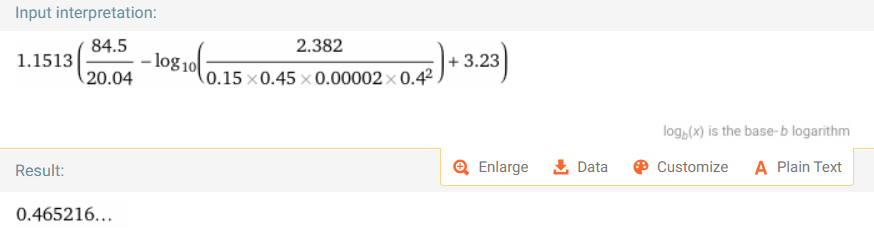

I am unsure why I am unable to replicate Sm value calculated in the textbook, but our calculated Sm is different for the reasons listed above
---
Sz can be calculated from 
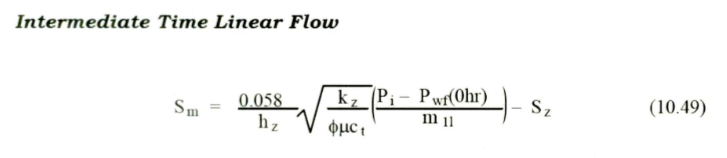

where Sm + Sz = 0.058/hz * sqrt(kz/phi/mu/ct)*(ITLF_intercept/slope_ITLF)

In [425]:
Sm_plus_Sz = 0.058/formation_pay_thickness * np.sqrt(kz/porosity/oil_viscosity / compressibility) * (intercept_itlf / slope_itlf)
print(f'Calculated Sm + Sz: {Sm_plus_Sz:.4f}')

textbook_Sm_plus_Sz = 0.058/40 * np.sqrt(0.89/porosity/oil_viscosity / compressibility) * (62.36 / 23.35)
print(f'Calculated Sm + Sz (Textbook): {textbook_Sm_plus_Sz:.4f}')

Sz = Sm_plus_Sz - Sm
print('##########################')
print(f'Calculated Sz: {Sz:.4f}')
print(f'Textbook Sz = 3.31')

Calculated Sm + Sz: 7.1983
Calculated Sm + Sz (Textbook): 3.1442
##########################
Calculated Sz: 2.2528
Textbook Sz = 3.31
